In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle



In [2]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the  test sets from SDF files
test_df = load_sdf_to_df(r'D:\Riset QSAR - TTX\Machine Learning (Done)\Respiratory\Dataset\test_set_respiratory_irritatio_features_rdkitcdk.sdf')

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string


test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

def string_to_list(descriptor):
    if isinstance(descriptor, str):
        return list(map(float, descriptor.strip('[]').split(',')))
    return descriptor

# Apply the function to the 'Modred_Descriptor' column
test_df['Modred_Descriptor'] = test_df['Modred_Descriptor'].apply(string_to_list)

# Convert 'Modred_Descriptor' column to a NumPy array
data_modred_test = np.array(test_df['Modred_Descriptor'].tolist())


print("Test DataFrame:")
print(test_df.head())


[16:06:39] WARNING: not removing hydrogen atom without neighbors
[16:06:39] WARNING: not removing hydrogen atom without neighbors


Test DataFrame:
                                                name Outcome    ID RowID  \
0                                N-methylmethanamine       1   568   568   
1       dimethoxy-(2-methylpropyl)-propan-2-ylsilane       1  1653  1653   
2                  cerium(4+);disulfate;tetrahydrate       1  1343  1343   
3  4,5,6,7-tetrachloro-3-[4-[(4,5,6,7-tetrachloro...       0  3312  3312   
4                     2-ethylhexyl carbonochloridate       1  1466  1466   

                                  Morgan_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 

In [3]:
test_df.keys()

Index(['name', 'Outcome', 'ID', 'RowID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'Molecular Weight',
       'logP', 'LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD',
       'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v',
       'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha',
       'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', 'MLogP',
       'nAtomP', 'naAromAtom', 'bpol', 'nB', 'ECCEN', 'fragC', 'nHBAcc',
       'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB',
       'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3'],
      dtype

In [4]:
data_modred_test.shape

test_df

,name,Outcome,ID,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES,Molecular Weight,logP,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,N-methylmethanamine,1,568,568,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7838422003386987, -0.7103490381116897, -0....",CNC,45.057849223999995,-0.1644000000000001,...,1.0,0.0,3.0,0.5,0.0,0.0,12.03,2.0,-0.176,1.0
1,dimethoxy-(2-methylpropyl)-propan-2-ylsilane,1,1653,1653,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4641784768228143, -0.5779053735880487, -0....",CO[Si](CC(C)C)(OC)C(C)C,190.138906474,2.7874000000000008,...,0.0,3.0,6.0,0.4,5.0,0.0,18.46,4.459431618637298,2.828,1.0
2,cerium(4+);disulfate;tetrahydrate,1,1343,1343,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.720757043809812, -0.5908509949324647, 0.631...",O.O.O.O.O=S(=O)([O-])[O-].O=S(=O)([O-])[O-].[C...,403.85115639599996,-5.974799999999997,...,4.0,0.0,3.0,0.999000000999,0.0,1.0,177.28,4.0,-5.396000000000001,0.0
3,"4,5,6,7-tetrachloro-3-[4-[(4,5,6,7-tetrachloro...",0,3312,3312,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0239046482374619, 1.6686578381813821, 1.407...",O=C1NC(=Nc2ccc(N=C3NC(=O)c4c(Cl)c(Cl)c(Cl)c(Cl...,637.7998968720002,8.557199999999998,...,2.0,0.0,0.0,0.4705882352941176,2.0,2.0,82.91999999999999,6.321928094887363,8.254000000000001,0.0
4,2-ethylhexyl carbonochloridate,1,1466,1466,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.3887036535475109, -0.3289511169646631, -0....",CCCCC(CC)COC(=O)Cl,192.091707464,3.5782000000000025,...,0.0,7.0,9.0,0.5,7.0,0.0,26.3,4.459431618637298,3.991000000000001,0.8888888888888888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,ethoxyethane;trifluoroborane,1,417,417,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.06827173844612727, -0.3384113787163518, -0...",CCOCC.FB(F)F,142.07768,1.9226,...,0.0,2.0,5.0,0.999000000999,2.0,0.0,9.23,3.807354922057604,2.402,1.0
730,"11-methoxy-6,8,16,20-tetraoxapentacyclo[10.8.0...",1,877,877,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.896192797148208, 1.2389627912494188, 1.2104...",COc1cc2c(c3oc(=O)c4c(c13)CCOC4=O)C1C=COC1O2,328.058302724,1.8604999999999996,...,0.0,0.0,2.0,0.4444444444444444,1.0,0.0,84.20000000000002,5.807354922057604,2.451,0.2941176470588235
731,2-ethoxy-N'-hydroxybenzenecarboximidamide,0,2095,2095,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.13827319667474838, 0.051450987155869904, -...",CCOc1ccccc1C(N)=NO,180.089877624,1.1798,...,2.0,2.0,4.0,0.4285714285714285,3.0,0.0,67.84,4.700439718141093,1.807,0.2222222222222222
732,"4,5-dichloro-2-octyl-1,2-thiazol-3-one",1,1585,1585,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.3107322076193348, -0.18953673325556725, -0...",CCCCCCCCn1sc(Cl)c(Cl)c1=O,281.040790524,4.577100000000004,...,0.0,8.0,8.0,0.4545454545454545,7.0,0.0,50.24,5.0,4.927,0.7272727272727273


In [5]:
test_df = test_df.rename(columns={'Outcome': 'Outcome'})

test_df= test_df.sort_values(['Outcome'], ascending=True)
#moldf['RowID'] = moldf.index
test_df.head(100)

,name,Outcome,ID,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES,Molecular Weight,logP,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
733,1-morpholin-4-ylprop-2-en-1-one,0,2504,2504,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.30160993254153096, -0.2353443164742702, -0...",C=CC(=O)N1CCOCC1,141.078978592,0.031199999999999894,...,0.0,3.0,4.0,0.5,2.0,0.0,29.540000000000003,4.321928094887363,-0.256,0.5714285714285714
328,"potassium;1,4-bis(2-ethylhexoxy)-1,4-dioxobuta...",0,3641,3641,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5945815758915566, 0.24264785624263005, 0.45...",CCCCC(CC)COC(=O)CC(C(=O)OCC(CC)CCCC)S(=O)(=O)[...,460.18970620399995,0.8135000000000032,...,0.0,7.0,18.0,0.999000000999,18.0,2.0,118.18,5.754887502163469,5.040000000000001,0.9
327,ethoxybenzene,0,3478,3478,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.45716872860513347, -0.30704314238180525, -...",CCOc1ccccc1,122.07316494,2.0853,...,0.0,2.0,3.0,0.5,2.0,0.0,9.23,4.169925001442312,2.3600000000000003,0.25
326,"2-(6-methoxy-1-benzofuran-2-yl)-1,3-dimethyl-5...",0,2815,2815,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0223682650664636, 1.10154004159331, 1.04134...",CC(=O)[O-].COc1ccc2cc(-c3n(C)c4cc(S(C)(=O)=O)c...,430.119857424,1.5842999999999996,...,0.0,2.0,3.0,0.999000000999,3.0,0.0,113.83,6.0,3.629,0.238095238095238
325,"(8R,9S,13S,14S,17S)-17-hydroxy-13-methyl-2,4,6...",0,3021,3021,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.08382761805248752, 0.1545180493979515, 0.0...",CC12CCC3C4=C(CCC3C1CCC2O)CC(=O)CC4,274.193280072,3.633200000000002,...,1.0,0.0,0.0,0.5,0.0,0.0,37.3,5.523561956057013,2.459,0.8333333333333334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
263,"3-methyl-1,2-benzothiazole 1,1-dioxide",0,1819,1819,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.1443227054105551, -0.20397608013972363, 0....",CC1=NS(=O)(=O)c2ccccc21,181.019749464,1.1979,...,0.0,0.0,0.0,0.4,0.0,0.0,54.88,4.700439718141093,1.298,0.125
281,methyl (E)-3-(4-hydroxyphenyl)prop-2-enoate,0,2844,2844,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.0760496782493074, 0.029045104059765205, -0...",COC(=O)C=Cc1ccc(O)cc1,178.06299418,1.5783999999999998,...,1.0,3.0,5.0,0.4444444444444444,3.0,0.0,46.53,4.700439718141093,1.824,0.1
279,4-tert-butylphenol,0,2024,2024,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.41827902958923285, -0.2353443164742702, -0...",CC(C)(C)c1ccc(O)cc1,150.104465068,2.689700000000001,...,1.0,3.0,3.0,0.5,1.0,0.0,20.23,4.459431618637298,3.4330000000000007,0.4
277,"6-(dimethylamino)-3,3-bis[4-(dimethylamino)phe...",0,2781,2781,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.6861884224623447, 1.1851886718187674, 1.001...",CN(C)c1ccc(C2(c3ccc(N(C)C)cc3)OC(=O)c3cc(N(C)C...,415.22597716800004,4.346900000000004,...,0.0,0.0,3.0,0.5,5.0,1.0,36.02,6.08746284125034,5.815,0.2692307692307692


Classes                          :  ['0' '1']
Number of cpds in each class     :  [340 394]
Total number of cpds             :  734


{'0': 0, '1': 1}

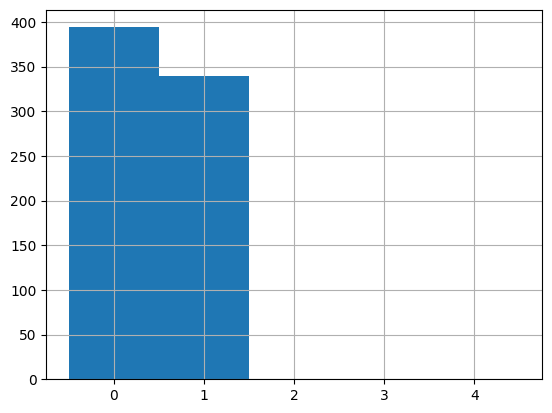

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(test_df['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( test_df['Outcome'] )



print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S = test_df['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

#graph
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [7]:
x_rdkitcdk = test_df.drop(columns=['name', 'Outcome', 'ID', 'RowID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'SMILES', 'Molecular Weight','logP'])

In [8]:
print(x_rdkitcdk)

              LabuteASA                TPSA                 AMW  \
733   60.26837052824971  29.540000000000003              141.17   
328  218.77448656586964  109.80000000000001  460.67400000000026   
327  55.274832577797056                9.23  122.16699999999996   
326   173.3850903317018              105.45  430.48200000000014   
325  121.18609517851051                37.3  274.40400000000005   
..                  ...                 ...                 ...   
336   68.07279905276974                74.6  166.13199999999998   
335   49.83902892936323                26.3  116.15999999999998   
334  151.67332518906633              190.52  418.86899999999997   
395  19.042517254711225                 0.0              50.488   
366  44.878800879441414               52.04  102.18100000000001   

    NumLipinskiHBA NumLipinskiHBD NumRotatableBonds NumHBD NumHBA  \
733              2              0                 1      0      2   
328              7              0                16      

In [9]:
x_rdkitcdk  = x_rdkitcdk.apply(lambda row: row.values, axis=1).tolist()

test_df['rdkit_cdk'] = x_rdkitcdk 

# Display the updated DataFrame
print(test_df)

                                                  name Outcome    ID RowID  \
733                    1-morpholin-4-ylprop-2-en-1-one       0  2504  2504   
328  potassium;1,4-bis(2-ethylhexoxy)-1,4-dioxobuta...       0  3641  3641   
327                                      ethoxybenzene       0  3478  3478   
326  2-(6-methoxy-1-benzofuran-2-yl)-1,3-dimethyl-5...       0  2815  2815   
325  (8R,9S,13S,14S,17S)-17-hydroxy-13-methyl-2,4,6...       0  3021  3021   
..                                                 ...     ...   ...   ...   
336                      benzene-1,3-dicarboxylic acid       1   534   534   
335                                     pentyl formate       1   788   788   
334  potassium;dizinc;dioxido(dioxo)chromium;hydroxide       1  1357  1357   
395                                      chloromethane       1    65    65   
366                    2,2-dimethylpropane-1,3-diamine       1  1147  1147   

                                    Morgan_Descriptors  \
733  

In [10]:
y_test= np.int32((S))
x_test_morgan = np.array(list(test_df['Morgan_Descriptors']))
x_test_macckeys = np.array(list(test_df['MACCS_Descriptors']))
x_test_modred= np.array(list(test_df['Modred_Descriptor']))
x_test_rdkit_cdk = np.array(list(test_df['rdkit_cdk']))

In [11]:
x_test_rdkit_cdk

array([['60.26837052824971', '29.540000000000003', '141.17', ...,
        '4.321928094887363', '-0.256', '0.5714285714285714'],
       ['218.77448656586964', '109.80000000000001', '460.67400000000026',
        ..., '5.754887502163469', '5.040000000000001', '0.9'],
       ['55.274832577797056', '9.23', '122.16699999999996', ...,
        '4.169925001442312', '2.3600000000000003', '0.25'],
       ...,
       ['151.67332518906633', '190.52', '418.86899999999997', ..., '4.0',
        '-2.063', '0.0'],
       ['19.042517254711225', '0.0', '50.488', ..., '1.0', '1.04', '1.0'],
       ['44.878800879441414', '52.04', '102.18100000000001', ...,
        '3.584962500721156', '-0.292', '1.0']], dtype=object)

In [12]:
import joblib
import numpy as np
import ast

# Function to ensure data is a NumPy array
def ensure_numpy_array(data):
    if isinstance(data, np.ndarray):
        return data
    elif isinstance(data, list):
        return np.array(data)
    elif hasattr(data, 'to_numpy'):  # For Pandas DataFrame
        return data.to_numpy()
    else:
        raise ValueError("Data format not recognized. Ensure it is a list, numpy array, or pandas DataFrame.")

# Function to check if all elements are numerical
def check_numerical(data):
    if not np.issubdtype(data.dtype, np.number):
        raise ValueError("Data contains non-numerical values. Ensure all elements are numerical.")

# Function to convert string representations of lists to numerical arrays
def parse_string_lists(data):
    parsed_data = []
    for item in data:
        if isinstance(item, str):
            try:
                parsed_item = ast.literal_eval(item)
                parsed_data.append(parsed_item)
            except (ValueError, SyntaxError):
                raise ValueError(f"Cannot parse value '{item}'")
        else:
            parsed_data.append(item)
    return np.array(parsed_data)

# Ensure training data is properly formatted
x_test_morgan = ensure_numpy_array(x_test_morgan)
x_test_macckeys = ensure_numpy_array(x_test_macckeys)
x_test_modred = ensure_numpy_array(x_test_modred)

check_numerical(x_test_morgan)
check_numerical(x_test_macckeys)

# Parse and convert string lists in x_test_modred
x_test_modred = parse_string_lists(x_test_modred)
check_numerical(x_test_modred)





In [13]:
x_test = np.concatenate((x_test_morgan, x_test_macckeys, x_test_modred), axis=1)

In [14]:
#load model - all included
import joblib

# Base paths
fingerprint_path = r"D:\Riset QSAR - TTX\Machine Learning (Done)\Respiratory\Model\Descriptor"
phys_path        = r"D:\Riset QSAR - TTX\Machine Learning (Done)\Respiratory\Model\Physiochemical"

# descriptor
rf_morgan   = joblib.load(fr"{fingerprint_path}\Model_Respiratory_RF_morgan.pkl")  
rf_maccs    = joblib.load(fr"{fingerprint_path}\Model_Respiratory_RF_maccskey.pkl")
rf_modred   = joblib.load(fr"{fingerprint_path}\Model_Respiratory_RF_modred.pkl")

svm_morgan  = joblib.load(fr"{fingerprint_path}\Model_Respiratory_SVM_morgan.pkl")  
svm_maccs   = joblib.load(fr"{fingerprint_path}\Model_Respiratory_SVM_maccskey.pkl")
svm_modred  = joblib.load(fr"{fingerprint_path}\Model_Respiratory_SVM_modred.pkl")

xgb_morgan  = joblib.load(fr"{fingerprint_path}\Model_Respiratory_XGB_morgan.pkl")  
xgb_maccs   = joblib.load(fr"{fingerprint_path}\Model_Respiratory_XGB_maccskey.pkl")
xgb_modred  = joblib.load(fr"{fingerprint_path}\Model_Respiratory_XGB_modred.pkl")

nn_morgan   = joblib.load(fr"{fingerprint_path}\Model_Respiratory_NN_morgan.pkl")  
nn_maccs    = joblib.load(fr"{fingerprint_path}\Model_Respiratory_NN_maccskey.pkl")
nn_modred   = joblib.load(fr"{fingerprint_path}\Model_Respiratory_NN_modred.pkl")

lgbm_morgan = joblib.load(fr"{fingerprint_path}\Model_Respiratory_LGBM_morgan.pkl")  
lgbm_maccs  = joblib.load(fr"{fingerprint_path}\Model_Respiratory_LGBM_maccskey.pkl")
lgbm_modred = joblib.load(fr"{fingerprint_path}\Model_Respiratory_LGBM_modred.pkl")

# physiochemical
rf_phys   = joblib.load(fr"{phys_path}\Model_Respiratory_RF_rdkit_cdk.pkl")
svm_phys  = joblib.load(fr"{phys_path}\Model_Respiratory_SVM_rdkit_cdk.pkl")
xgb_phys  = joblib.load(fr"{phys_path}\Model_Respiratory_XGB_rdkit_cdk.pkl")
nn_phys   = joblib.load(fr"{phys_path}\Model_Respiratory_NN_rdkit_cdk.pkl")
lgbm_phys = joblib.load(fr"{phys_path}\Model_Respiratory_LGBM_rdkit_cdk.pkl")


In [15]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score, classification_report
y_true = test_df['Outcome'].astype(int) 

In [16]:
test_df

,name,Outcome,ID,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES,Molecular Weight,logP,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,rdkit_cdk
733,1-morpholin-4-ylprop-2-en-1-one,0,2504,2504,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.30160993254153096, -0.2353443164742702, -0...",C=CC(=O)N1CCOCC1,141.078978592,0.031199999999999894,...,3.0,4.0,0.5,2.0,0.0,29.540000000000003,4.321928094887363,-0.256,0.5714285714285714,"[60.26837052824971, 29.540000000000003, 141.17..."
328,"potassium;1,4-bis(2-ethylhexoxy)-1,4-dioxobuta...",0,3641,3641,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5945815758915566, 0.24264785624263005, 0.45...",CCCCC(CC)COC(=O)CC(C(=O)OCC(CC)CCCC)S(=O)(=O)[...,460.18970620399995,0.8135000000000032,...,7.0,18.0,0.999000000999,18.0,2.0,118.18,5.754887502163469,5.040000000000001,0.9,"[218.77448656586964, 109.80000000000001, 460.6..."
327,ethoxybenzene,0,3478,3478,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.45716872860513347, -0.30704314238180525, -...",CCOc1ccccc1,122.07316494,2.0853,...,2.0,3.0,0.5,2.0,0.0,9.23,4.169925001442312,2.3600000000000003,0.25,"[55.274832577797056, 9.23, 122.16699999999996,..."
326,"2-(6-methoxy-1-benzofuran-2-yl)-1,3-dimethyl-5...",0,2815,2815,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0223682650664636, 1.10154004159331, 1.04134...",CC(=O)[O-].COc1ccc2cc(-c3n(C)c4cc(S(C)(=O)=O)c...,430.119857424,1.5842999999999996,...,2.0,3.0,0.999000000999,3.0,0.0,113.83,6.0,3.629,0.238095238095238,"[173.3850903317018, 105.45, 430.48200000000014..."
325,"(8R,9S,13S,14S,17S)-17-hydroxy-13-methyl-2,4,6...",0,3021,3021,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.08382761805248752, 0.1545180493979515, 0.0...",CC12CCC3C4=C(CCC3C1CCC2O)CC(=O)CC4,274.193280072,3.633200000000002,...,0.0,0.0,0.5,0.0,0.0,37.3,5.523561956057013,2.459,0.8333333333333334,"[121.18609517851051, 37.3, 274.40400000000005,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,"benzene-1,3-dicarboxylic acid",1,534,534,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.009507659585673955, 0.08730040010963741, -0...",O=C(O)c1cccc(C(=O)O)c1,166.026608672,1.083,...,0.0,3.0,0.5,2.0,0.0,74.6,4.584962500721156,1.2520000000000002,0.0,"[68.07279905276974, 74.6, 166.13199999999998, ..."
335,pentyl formate,1,788,788,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4727246082114937, -0.46836550067375904, -0...",CCCCCOC=O,116.083729624,1.3496,...,5.0,8.0,0.4285714285714285,5.0,0.0,26.3,3.807354922057604,1.924,0.8333333333333334,"[49.83902892936323, 26.3, 116.15999999999998, ..."
334,potassium;dizinc;dioxido(dioxo)chromium;hydroxide,1,1357,1357,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, ...","[0.6093779027451264, -0.6639556801715201, 0.63...",[K+].[OH-].[O]=[Cr](=[O])([O-])[O-].[O]=[Cr](=...,415.66506269200005,-8.414,...,0.0,3.0,0.999000000999,0.0,0.0,160.52,4.0,-2.063,0.0,"[151.67332518906633, 190.52, 418.8689999999999..."
395,chloromethane,1,65,65,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8476021019351382, -0.7427130914727299, -0....",CCl,49.992327775999996,0.855,...,0.0,2.0,0.0,0.0,0.0,0.0,1.0,1.04,1.0,"[19.042517254711225, 0.0, 50.488, 0, 0, 0, 0, ..."


In [17]:
#physiochemical consensus here - only phys
#descriptor not yet included here!
# Predict with all phys models (RF, SVM, XGB, NN, LGBM)


#PHYSICOCHEMICAL CONSENSUS
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_phys_models(test_df):
    # Get probabilities from each phys model
    rf_probs   = rf_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    svm_probs  = svm_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs  = xgb_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    nn_probs   = nn_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs = lgbm_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # Calculate mean probability across all phys models
    consensus_physicochemical_probs = np.mean(
        [rf_probs, svm_probs, xgb_probs, nn_probs, lgbm_probs],
        axis=0
    )

    # Convert mean probabilities to final class predictions (threshold = 0.5)
    final_predictions = (consensus_physicochemical_probs > 0.5).astype(int)

    return final_predictions, consensus_physicochemical_probs

# ==============================
# Run prediction
# ==============================
final_predictions, consensus_physicochemical_probs = predict_with_phys_models(test_df)
test_df['Phys_Predictions'] = final_predictions
test_df['Phys_Consensus_Probabilities'] = consensus_physicochemical_probs

y_true = test_df['Outcome'].astype(int)

# ==============================
# Evaluate performance
# ==============================
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, consensus_physicochemical_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)


Confusion Matrix:
[[274 120]
 [107 233]]
Accuracy: 0.6907356948228883
AUC Score: 0.7508808599581964
F1 Score: 0.6724386724386724
Sensitivity: 0.6852941176470588
Specificity: 0.6954314720812182
CCR (Correct Classification Rate): 0.6903627948641385
PPV (Positive Predictive Value): 0.660056657223796
NPV (Negative Predictive Value): 0.7191601049868767


In [18]:
# RF
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Prediction Function 
def predict_probabilities_rf_from_pkl(test_df, rf_morgan, rf_maccs, rf_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :rf_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :rf_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :rf_modred.n_features_in_]

    return {
        "Morgan": rf_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  rf_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": rf_modred.predict_proba(X_modred)[:, 1]
    }

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }


# Consensus Function 
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_rf = predict_probabilities_rf_from_pkl(
    test_df,
    rf_morgan,
    rf_maccs,
    rf_modred
)

# Results
for model_name, y_prob in probs_rf.items():
    print(f"\n{model_name} RF Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_rf = consensus_probability(probs_rf)
consensus_metrics_rf = evaluate_model(y_true, consensus_probs_rf)

print("\nCONSENSUS RF (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_rf.items():
    print(f"{k}: {v}")



Morgan RF Performance
Confusion Matrix: [[274 120]
 [103 237]]
Accuracy: 0.6961852861035422
AUC: 0.7543557778441325
F1 Score: 0.6800573888091822
Sensitivity: 0.6970588235294117
Specificity: 0.6954314720812182
CCR: 0.696245147805315
PPV (Precision): 0.6638655462184874
NPV: 0.726790450928382

MACCS RF Performance
Confusion Matrix: [[286 108]
 [109 231]]
Accuracy: 0.7043596730245232
AUC: 0.74498730964467
F1 Score: 0.6804123711340206
Sensitivity: 0.6794117647058824
Specificity: 0.7258883248730964
CCR: 0.7026500447894894
PPV (Precision): 0.6814159292035398
NPV: 0.7240506329113924

Modred RF Performance
Confusion Matrix: [[275 119]
 [ 91 249]]
Accuracy: 0.7138964577656676
AUC: 0.7560988354732756
F1 Score: 0.7033898305084746
Sensitivity: 0.7323529411764705
Specificity: 0.6979695431472082
CCR: 0.7151612421618394
PPV (Precision): 0.6766304347826086
NPV: 0.7513661202185792

CONSENSUS RF (Morgan + MACCS + Modred)
Confusion Matrix: [[283 111]
 [ 96 244]]
Accuracy: 0.717983651226158
AUC: 0.7754553

In [20]:
# SVM
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, svm_morgan, svm_maccs, svm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :svm_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :svm_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :svm_modred.n_features_in_]

    return {
        "Morgan": svm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  svm_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": svm_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_svm = predict_probabilities_from_pkl(
    test_df,
    svm_morgan,
    svm_maccs,
    svm_modred
)

for model_name, y_prob in probs_svm.items():
    print(f"\n{model_name} SVM Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_svm = consensus_probability(probs_svm)
consensus_metrics_svm = evaluate_model(y_true, consensus_probs_svm)

print("\nCONSENSUS SVM (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_svm.items():
    print(f"{k}: {v}")



Morgan SVM Performance
Confusion Matrix: [[279 115]
 [110 230]]
Accuracy: 0.6934604904632152
AUC: 0.7485368766796058
F1 Score: 0.6715328467153284
Sensitivity (Recall+): 0.6764705882352942
Specificity (Recall-): 0.7081218274111675
CCR: 0.6922962078232309
PPV (Precision): 0.6666666666666666
NPV: 0.7172236503856041

MACCS SVM Performance
Confusion Matrix: [[281 113]
 [ 93 247]]
Accuracy: 0.7193460490463215
AUC: 0.7617460435951031
F1 Score: 0.7057142857142857
Sensitivity (Recall+): 0.7264705882352941
Specificity (Recall-): 0.7131979695431472
CCR: 0.7198342788892207
PPV (Precision): 0.6861111111111111
NPV: 0.7513368983957219

Modred SVM Performance
Confusion Matrix: [[271 123]
 [ 95 245]]
Accuracy: 0.7029972752043597
AUC: 0.7651388474171394
F1 Score: 0.692090395480226
Sensitivity (Recall+): 0.7205882352941176
Specificity (Recall-): 0.6878172588832487
CCR: 0.7042027470886831
PPV (Precision): 0.6657608695652174
NPV: 0.7404371584699454

CONSENSUS SVM (Morgan + MACCS + Modred)
Confusion Matrix

In [21]:
# XGB
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Prediction Function 
def predict_probabilities_from_pkl(test_df, xgb_morgan, xgb_maccs, xgb_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :xgb_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :xgb_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :xgb_modred.n_features_in_]

    return {
        "Morgan": xgb_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  xgb_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": xgb_modred.predict_proba(X_modred)[:, 1]
    }

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# Consensus Function 
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_xgb = predict_probabilities_from_pkl(
    test_df,
    xgb_morgan,
    xgb_maccs,
    xgb_modred
)

# Results
for model_name, y_prob in probs_xgb.items():
    print(f"\n{model_name} XGB Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")
consensus_probs_xgb = consensus_probability(probs_xgb)
consensus_metrics_xgb = evaluate_model(y_true, consensus_probs_xgb)

print("\nCONSENSUS XGB (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_xgb.items():
    print(f"{k}: {v}")




Morgan XGB Performance
Confusion Matrix: [[273 121]
 [109 231]]
Accuracy: 0.6866485013623979
AUC: 0.7460062705285161
F1 Score: 0.6676300578034682
Sensitivity (Recall+): 0.6794117647058824
Specificity (Recall-): 0.6928934010152284
CCR: 0.6861525828605555
PPV (Precision): 0.65625
NPV: 0.7146596858638743

MACCS XGB Performance
Confusion Matrix: [[274 120]
 [101 239]]
Accuracy: 0.6989100817438693
AUC: 0.7611115258286055
F1 Score: 0.6838340486409156
Sensitivity (Recall+): 0.7029411764705882
Specificity (Recall-): 0.6954314720812182
CCR: 0.6991863242759032
PPV (Precision): 0.6657381615598886
NPV: 0.7306666666666667

Modred XGB Performance
Confusion Matrix: [[278 116]
 [ 95 245]]
Accuracy: 0.7125340599455041
AUC: 0.7635861451179455
F1 Score: 0.6990014265335235
Sensitivity (Recall+): 0.7205882352941176
Specificity (Recall-): 0.7055837563451777
CCR: 0.7130859958196476
PPV (Precision): 0.6786703601108033
NPV: 0.7453083109919572

CONSENSUS XGB (Morgan + MACCS + Modred)
Confusion Matrix: [[279 11

In [22]:
# NN 
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Prediction Function 
def predict_probabilities_from_pkl(test_df, nn_morgan, nn_maccs, nn_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :nn_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :nn_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :nn_modred.n_features_in_]

    return {
        "Morgan": nn_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  nn_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": nn_modred.predict_proba(X_modred)[:, 1]
    }

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# Consensus Function 
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs = predict_probabilities_from_pkl(
    test_df,
    nn_morgan,
    nn_maccs,
    nn_modred
)

# Results
for model_name, y_prob in probs.items():
    print(f"\n{model_name} Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_nn = consensus_probability(probs)
consensus_metrics_nn = evaluate_model(y_true, consensus_probs_nn)

print("\n CONSENSUS NN (Morgan + MACCS + Modred) ")
for k, v in consensus_metrics_nn.items():
    print(f"{k}: {v}")



Morgan Performance
Confusion Matrix: [[232 162]
 [116 224]]
Accuracy: 0.6212534059945504
AUC: 0.6819834278889221
F1 Score: 0.6170798898071626
Sensitivity (Recall+): 0.6588235294117647
Specificity (Recall-): 0.5888324873096447
CCR: 0.6238280083607046
PPV (Precision): 0.5803108808290155
NPV: 0.6666666666666666

MACCS Performance
Confusion Matrix: [[245 149]
 [100 240]]
Accuracy: 0.6607629427792916
AUC: 0.7140228426395939
F1 Score: 0.6584362139917695
Sensitivity (Recall+): 0.7058823529411765
Specificity (Recall-): 0.6218274111675127
CCR: 0.6638548820543446
PPV (Precision): 0.6169665809768637
NPV: 0.7101449275362319

Modred Performance
Confusion Matrix: [[252 142]
 [ 95 245]]
Accuracy: 0.6771117166212534
AUC: 0.735495670349358
F1 Score: 0.6740027510316369
Sensitivity (Recall+): 0.7205882352941176
Specificity (Recall-): 0.6395939086294417
CCR: 0.6800910719617796
PPV (Precision): 0.6330749354005168
NPV: 0.7262247838616714

 CONSENSUS NN (Morgan + MACCS + Modred) 
Confusion Matrix: [[251 143

In [23]:
# LGBM - Consensus
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# Prediction Function (PKL-based)
# ==============================
def predict_probabilities_from_pkl(test_df, lgbm_morgan, lgbm_maccs, lgbm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :lgbm_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :lgbm_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :lgbm_modred.n_features_in_]

    return {
        "Morgan": lgbm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  lgbm_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": lgbm_modred.predict_proba(X_modred)[:, 1]
    }

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# Consensus Function (Neutral)
# ==============================
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

# ==============================
# RUN PREDICTION
# ==============================
probs = predict_probabilities_from_pkl(
    test_df,
    lgbm_morgan,
    lgbm_maccs,
    lgbm_modred
)

# ==============================
# PRINT INDIVIDUAL MODEL RESULTS
# ==============================
for model_name, y_prob in probs.items():
    print(f"\n===== {model_name} Performance =====")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

# ==============================
# CONSENSUS RESULT
# ==============================
consensus_probs_lgbm = consensus_probability(probs)
consensus_metrics_lgbm = evaluate_model(y_true, consensus_probs_lgbm)

print("\n===== CONSENSUS LGBM (Morgan + MACCS + Modred) =====")
for k, v in consensus_metrics_lgbm.items():
    print(f"{k}: {v}")



===== Morgan Performance =====
Confusion Matrix: [[268 126]
 [122 218]]
Accuracy: 0.662125340599455
AUC: 0.7249066885637504
F1 Score: 0.6374269005847953
Sensitivity (Recall+): 0.6411764705882353
Specificity (Recall-): 0.6802030456852792
CCR: 0.6606897581367572
PPV (Precision): 0.6337209302325582
NPV: 0.6871794871794872

===== MACCS Performance =====
Confusion Matrix: [[263 131]
 [ 96 244]]
Accuracy: 0.6907356948228883
AUC: 0.7509853687667961
F1 Score: 0.6825174825174826
Sensitivity (Recall+): 0.7176470588235294
Specificity (Recall-): 0.6675126903553299
CCR: 0.6925798745894296
PPV (Precision): 0.6506666666666666
NPV: 0.7325905292479109

===== Modred Performance =====
Confusion Matrix: [[268 126]
 [ 88 252]]
Accuracy: 0.7084468664850136
AUC: 0.7636682591818452
F1 Score: 0.7019498607242339
Sensitivity (Recall+): 0.7411764705882353
Specificity (Recall-): 0.6802030456852792
CCR: 0.7106897581367573
PPV (Precision): 0.6666666666666666
NPV: 0.7528089887640449

===== CONSENSUS LGBM (Morgan + M

In [24]:
# ==============================
# CONSENSUS ALL (RF + SVM + XGB + NN + LGBM)
# ==============================
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# STACK ALL MODEL CONSENSUS
# ==============================
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

# ==============================
# FINAL CONSENSUS (MEAN)
# ==============================
consensus_all_probs = all_model_probs.mean(axis=0)

# ==============================
# EVALUATION
# ==============================
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")


CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)
Confusion Matrix: [[277 117]
 [ 92 248]]
Accuracy: 0.715258855585831
AUC: 0.7776873693639893
F1 Score: 0.7035460992907802
Sensitivity (Recall+): 0.7294117647058823
Specificity (Recall-): 0.7030456852791879
CCR: 0.7162287249925351
PPV (Precision): 0.6794520547945205
NPV: 0.7506775067750677


In [25]:
# PHYSICOCHEMICAL + DESCRIPTOR

import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Evaluation Function 
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# STACK CONSENSUS PROBABILITIES
all_consensus_stack = np.vstack([
    consensus_physicochemical_probs,
    consensus_all_probs
])

# FINAL CONSENSUS (MEAN)
all_consensus_probs = all_consensus_stack.mean(axis=0)

# EVALUATION
all_consensus_metrics = evaluate_model(
    y_true,
    all_consensus_probs  
)

print("CONSENSUS: PHYSICOCHEMICAL + DESCRIPTOR")
for k, v in all_consensus_metrics.items():
    print(f"{k}: {v}")



CONSENSUS: PHYSICOCHEMICAL + DESCRIPTOR
Confusion Matrix: [[271 123]
 [ 97 243]]
Accuracy: 0.7002724795640327
AUC: 0.7769632726186921
F1 Score: 0.6883852691218131
Sensitivity (Recall+): 0.7147058823529412
Specificity (Recall-): 0.6878172588832487
CCR: 0.7012615706180949
PPV (Precision): 0.6639344262295082
NPV: 0.7364130434782609


In [ ]:
#read accross

In [26]:
from rdkit import Chem, DataStructs
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Buat fingerprint dari test set (Morgan misalnya)
test_fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(smi)) for smi in test_df['SMILES']]
y_true = test_df['Outcome'].astype(int).values

def read_across_predict_leave_one_out(idx, test_fps, y_true, k=5):
    sims = [DataStructs.FingerprintSimilarity(test_fps[idx], fp) for fp in test_fps]
    sims[idx] = -1  # abaikan dirinya sendiri
    top_idx = np.argsort(sims)[-k:]
    return np.mean(y_true[top_idx])

# Probabilitas prediksi untuk semua test (leave-one-out)
consensus_probs_ra = np.array([
    read_across_predict_leave_one_out(i, test_fps, y_true, k=5) 
    for i in range(len(test_fps))
])

# Konversi ke prediksi biner
final_predictions_ra = (consensus_probs_ra >= 0.5).astype(int)

# Fungsi evaluasi sesuai format yang diinginkan
def evaluate_performance(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    accuracy = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # Recall+
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # Recall-
    ccr = (sensitivity + specificity) / 2
    
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0           # Precision
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    
    return {
        "Accuracy": accuracy,
        "AUC": auc,
        "F1 Score": f1,
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": ccr,
        "PPV (Precision)": ppv,
        "NPV": npv
    }

# Evaluasi
ensemble_performance_ra = evaluate_performance(y_true, final_predictions_ra, consensus_probs_ra)

print("\n=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===")
for metric, value in ensemble_performance_ra.items():
    print(f"{metric}: {value}")


[16:07:24] WARNING: not removing hydrogen atom without neighbors
[16:07:24] WARNING: not removing hydrogen atom without neighbors



=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===
Accuracy: 0.6512261580381471
AUC: 0.6865332935204538
F1 Score: 0.6061538461538462
Sensitivity (Recall+): 0.5794117647058824
Specificity (Recall-): 0.7131979695431472
CCR: 0.6463048671245148
PPV (Precision): 0.635483870967742
NPV: 0.6627358490566038


In [27]:
# READ-ACROSS (Leave-One-Out, Tanimoto)
from rdkit import Chem, DataStructs
import numpy as np

test_fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(smi)) for smi in test_df['SMILES']]
y_true = test_df['Outcome'].astype(int).values

def read_across_predict_leave_one_out(idx, test_fps, y_true, k=5):
    sims = [DataStructs.FingerprintSimilarity(test_fps[idx], fp) for fp in test_fps]
    sims[idx] = -1  # abaikan dirinya sendiri
    top_idx = np.argsort(sims)[-k:]
    return np.mean(y_true[top_idx])

consensus_probs_ra = np.array([
    read_across_predict_leave_one_out(i, test_fps, y_true, k=5)
    for i in range(len(test_fps))
])

final_predictions_ra = (consensus_probs_ra >= 0.5).astype(int)
ensemble_performance_ra = evaluate_performance(y_true, final_predictions_ra, consensus_probs_ra)

print("\n=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===")
for metric, value in ensemble_performance_ra.items():
    print(f"{metric}: {value}")


# CONSENSUS ALL ALGORITHM (RF + SVM + XGB + NN + LGBM)
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

consensus_all_probs = all_model_probs.mean(axis=0)
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("\n=== Consensus All Algorithm (RF + SVM + XGB + NN + LGBM) Performance ===")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")


# PHYSICOCHEMICAL CONSENSUS
rf_probs   = rf_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
svm_probs  = svm_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
xgb_probs  = xgb_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
nn_probs   = nn_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
lgbm_probs = lgbm_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

consensus_physicochemical_probs = np.mean(
    [rf_probs, svm_probs, xgb_probs, nn_probs, lgbm_probs],
    axis=0
)

final_predictions_phys = (consensus_physicochemical_probs >= 0.5).astype(int)
ensemble_performance_phys = evaluate_performance(y_true, final_predictions_phys, consensus_physicochemical_probs)

print("\n=== Physicochemical Consensus (RF + SVM + XGB + NN + LGBM) Performance ===")
for metric, value in ensemble_performance_phys.items():
    print(f"{metric}: {value}")


# COMBINED CONSENSUS (RA + All Algorithm + Physicochemical)
consensus_ra_all_phys_probs = np.mean([
    consensus_probs_ra,
    consensus_all_probs,
    consensus_physicochemical_probs
], axis=0)

final_predictions_ra_all_phys = (consensus_ra_all_phys_probs >= 0.5).astype(int)
ensemble_performance_ra_all_phys = evaluate_performance(y_true, final_predictions_ra_all_phys, consensus_ra_all_phys_probs)

print("\n=== Combined Consensus (Read-Across + Consensus All Algorithm + Physicochemical) Performance ===")
for metric, value in ensemble_performance_ra_all_phys.items():
    print(f"{metric}: {value}")


[16:07:33] WARNING: not removing hydrogen atom without neighbors
[16:07:33] WARNING: not removing hydrogen atom without neighbors



=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===
Accuracy: 0.6512261580381471
AUC: 0.6865332935204538
F1 Score: 0.6061538461538462
Sensitivity (Recall+): 0.5794117647058824
Specificity (Recall-): 0.7131979695431472
CCR: 0.6463048671245148
PPV (Precision): 0.635483870967742
NPV: 0.6627358490566038

=== Consensus All Algorithm (RF + SVM + XGB + NN + LGBM) Performance ===
Confusion Matrix: [[277 117]
 [ 92 248]]
Accuracy: 0.715258855585831
AUC: 0.7776873693639893
F1 Score: 0.7035460992907802
Sensitivity (Recall+): 0.7294117647058823
Specificity (Recall-): 0.7030456852791879
CCR: 0.7162287249925351
PPV (Precision): 0.6794520547945205
NPV: 0.7506775067750677

=== Physicochemical Consensus (RF + SVM + XGB + NN + LGBM) Performance ===
Accuracy: 0.6907356948228883
AUC: 0.7508808599581964
F1 Score: 0.6724386724386724
Sensitivity (Recall+): 0.6852941176470588
Specificity (Recall-): 0.6954314720812182
CCR: 0.6903627948641385
PPV (Precision): 0.660056657223796
N